<a href="https://colab.research.google.com/github/ollamani/ApexMarket-Analytics-Segmentacion-RFM-y-Optimizacion-Transaccional/blob/main/Analytics_Transaccional_ECommerce_Segmentacion_RFM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Se importan las librerías necesarias para este proyecto.

In [12]:
import pandas as pd
import numpy as np
import sqlite3
from datetime import datetime, timedelta
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Caso de Estudio: Optimización Transaccional y Segmentación Avanzada en ApexMarket

## Fase 1: Ingeniería de Características y Simulación Conductual de Datos
En entornos corporativos, los datos transaccionales rara vez se presentan de forma homogénea o perfectamente limpia. Para simular un entorno de producción realista, este bloque de código genera un histórico de operaciones para la plataforma de E-Commerce **ApexMarket** abarcando el periodo de julio de 2024 a julio de 2026.

### Justificación de Componentes Técnicos y Estadísticos:
1. **Modelado de Retención (Distribución Geométrica):** En el comercio electrónico y la banca, la retención de usuarios sigue un comportamiento decreciente. Se utiliza `np.random.geometric(p=0.3)` para modelar el número de transacciones por cliente. Esto asegura que la mayoría de los usuarios registren pocas interacciones (comportamiento de abandono o *churn*), mientras que una minoría represente a los usuarios de alto valor o VIP.
2. **Restricciones de Integridad Temporal:** Se implementa una validación matemática de fechas donde la fecha de compra (`order_date`) se calcula dinámicamente como un desplazamiento aleatorio que ocurre *únicamente* en el intervalo de tiempo situado entre la fecha de alta del cliente (`signup_date`) y el cierre del estudio.
3. **Distribución de Peso en Cantidades:** A través de `np.random.choice`, se aplica una matriz de probabilidad implícita `[0.75, 0.20, 0.05]` para determinar el volumen de artículos por transacción, emulando la distribución orgánica de un carrito de compras real.

In [7]:
# Configurar una semilla para que los datos sean reproducibles
np.random.seed(42)

print("Iniciando la forja de datos para ApexMarket...")

# ---------------------------------------------------------
# 1. GENERACIÓN DE CLIENTES (CUSTOMERS)
# ---------------------------------------------------------
num_customers = 1000

customers_data = {
    'customer_id': np.arange(1, num_customers + 1),
    'customer_name': [f"Cliente_{i}" for i in range(1, num_customers + 1)],
    'segment': np.random.choice(['Consumer', 'Corporate', 'Home Office'], size=num_customers, p=[0.60, 0.25, 0.15]),
    # Simulamos fechas de registro escalonadas en los últimos 2 años
    'signup_date': [datetime(2024, 7, 11) + timedelta(days=int(np.random.randint(0, 600))) for _ in range(num_customers)]
}
df_customers = pd.DataFrame(customers_data)

# ---------------------------------------------------------
# 2. GENERACIÓN DE PRODUCTOS (PRODUCTS)
# ---------------------------------------------------------
products_list = [
    (101, 'Laptop Pro 15', 'Electronics', 1200.00),
    (102, 'Monitor 4K 27', 'Electronics', 350.00),
    (103, 'Teclado Mecánico RGB', 'Electronics', 85.00),
    (104, 'Audífonos Cancelación Ruido', 'Electronics', 150.00),
    (105, 'Silla Ergonómica Ejecutiva', 'Home Office', 250.00),
    (106, 'Escritorio Elevable', 'Home Office', 400.00),
    (107, 'Lámpara de Escritorio LED', 'Home Office', 35.00),
    (108, 'Mochila Impermeable Tech', 'Clothing', 65.00),
    (109, 'Chaqueta Térmica Ejecutiva', 'Clothing', 110.00),
    (110, 'Tenis Urbanos Confort', 'Clothing', 90.00)
]

df_products = pd.DataFrame(products_list, columns=['product_id', 'product_name', 'category', 'price'])

# ---------------------------------------------------------
# 3. GENERACIÓN DE ÓRDENES Y DETALLES (ORDERS & ORDER_ITEMS)
# ---------------------------------------------------------
num_orders = 3500
orders_list = []
items_list = []

order_id_counter = 5001
item_id_counter = 10001

# Para crear un comportamiento transaccional realista (unos compran mucho, otros nada)
# Usamos una distribución geométrica para asignar cuántas órdenes hace cada cliente
order_counts = np.random.geometric(p=0.3, size=num_customers)

for idx, customer in df_customers.iterrows():
    c_id = customer['customer_id']
    c_signup = customer['signup_date']

    # Limitar el número de órdenes máximas basadas en la distribución
    n_orders = min(order_counts[idx], 8)

    for _ in range(n_orders):
        # La fecha de la orden debe ser posterior a la fecha de registro del cliente
        days_after_signup = np.random.randint(0, (datetime(2026, 7, 11) - c_signup).days + 1)
        order_date = c_signup + timedelta(days=days_after_signup)

        shipping_cost = round(float(np.random.uniform(5.00, 35.00)), 2)

        orders_list.append([order_id_counter, c_id, order_date.strftime('%Y-%m-%d'), shipping_cost])

        # Cada orden puede tener entre 1 y 4 productos distintos (Items)
        n_items = np.random.randint(1, 5)
        chosen_products = df_products.sample(n_items)

        for _, prod in chosen_products.iterrows():
            qty = int(np.random.choice([1, 2, 3], p=[0.75, 0.20, 0.05]))
            u_price = prod['price']

            items_list.append([item_id_counter, order_id_counter, prod['product_id'], qty, u_price])
            item_id_counter += 1

        order_id_counter += 1

df_orders = pd.DataFrame(orders_list, columns=['order_id', 'customer_id', 'order_date', 'shipping_cost'])
df_order_items = pd.DataFrame(items_list, columns=['item_id', 'order_id', 'product_id', 'quantity', 'unit_price'])

print(f"¡Datos creados con éxito!")
print(f"Resumen del volumen: {len(df_customers)} Clientes | {len(df_products)} Productos | {len(df_orders)} Órdenes | {len(df_order_items)} Líneas de detalle transaccional.")

Iniciando la forja de datos para ApexMarket...
¡Datos creados con éxito!
Resumen del volumen: 1000 Clientes | 10 Productos | 3198 Órdenes | 7910 Líneas de detalle transaccional.


## Fase 2: Arquitectura y Persistencia en Base de Datos Relacional (SQL)
Una vez estructurados los datos en memoria mediante DataFrames de Pandas, el flujo de ingeniería de datos dicta que la información debe persistirse en una base de datos que garantice la integridad y consistencia de las transacciones.

### Puntos Clave del Diseño del Esquema:
1. **Habilitación de Restricciones (`PRAGMA foreign_keys = ON;`):** Por defecto, SQLite no penaliza las violaciones de llaves foráneas. Activar esta directiva es mandatorio para asegurar que no existan huérfanos transaccionales (por ejemplo, un artículo comprado que apunte a un código de producto inexistente).
2. **Normalización de Tablas:** Los datos se segmentan en cuatro entidades fundamentales: `customers`, `products`, `orders` y `order_items`, respetando las mejores prácticas de formas normales para mitigar la redundancia de datos.
3. **Mapeo Automatizado:** Se utiliza el método `.to_sql()` de Pandas conectado al motor nativo de SQLite para realizar la migración directa de los esquemas relacionales, uniendo las capacidades analíticas de Python con la robustez de almacenamiento de SQL.

In [8]:
# 1. Crear y conectar a la base de datos relacional local
conn = sqlite3.connect('apexmarket.db')
cursor = conn.cursor()

print("Inicializando arquitectura de base de datos relacional...")

# Activar el soporte de Llaves Foráneas en SQLite
cursor.execute("PRAGMA foreign_keys = ON;")

# 2. DDL - Creación de Tablas con restricciones de integridad relacional
# Añadir DROP TABLE IF EXISTS para asegurar una recreación limpia de la base de datos.
cursor.execute("DROP TABLE IF EXISTS order_items;")
cursor.execute("DROP TABLE IF EXISTS orders;")
cursor.execute("DROP TABLE IF EXISTS products;")
cursor.execute("DROP TABLE IF EXISTS customers;")

cursor.execute("""
CREATE TABLE IF NOT EXISTS customers (
    customer_id INTEGER PRIMARY KEY,
    customer_name VARCHAR(100),
    segment VARCHAR(50),
    signup_date DATE
);
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS products (
    product_id INTEGER PRIMARY KEY,
    product_name VARCHAR(100),
    category VARCHAR(50),
    price DECIMAL(10,2)
);
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS orders (
    order_id INTEGER PRIMARY KEY,
    customer_id INTEGER,
    order_date DATE,
    shipping_cost DECIMAL(10,2),
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
);
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS order_items (
    item_id INTEGER PRIMARY KEY,
    order_id INTEGER,
    product_id INTEGER,
    quantity INTEGER,
    unit_price DECIMAL(10,2),
    FOREIGN KEY (order_id) REFERENCES orders(order_id),
    FOREIGN KEY (product_id) REFERENCES products(product_id)
);
""")

conn.commit()

# 3. Mapeo y vaciado de los DataFrames de Pandas hacia las tablas SQL reales
df_customers.to_sql('customers', conn, if_exists='append', index=False)
df_products.to_sql('products', conn, if_exists='append', index=False)
df_orders.to_sql('orders', conn, if_exists='append', index=False)
df_order_items.to_sql('order_items', conn, if_exists='append', index=False)

print("¡Base de datos relacional conformada y poblada con éxito!")

Inicializando arquitectura de base de datos relacional...
¡Base de datos relacional conformada y poblada con éxito!


## Fase 3: Análisis Exploratorio de Datos (EDA)
En esta fase, realizamos la auditoría de calidad de datos (*Data Profiling*) y el descubrimiento de patrones comerciales. El EDA es el paso crítico donde validamos la integridad de nuestra base relacional antes de realizar cálculos de negocio complejos.

### Objetivos de esta etapa:
1. **Validación de Integridad:** Verificar que las uniones (JOINs) entre tablas sean consistentes y que el volumen de datos sea el esperado tras nuestra simulación.
2. **Análisis de Dispersión:** Identificar cuáles son los productos estrella y cómo se distribuye el volumen de ventas por segmento de cliente.
3. **Detección de Anomalías:** Confirmar que no existen registros huérfanos o transacciones con valores atípicos que puedan sesgar nuestro análisis posterior.

Las consultas a continuación utilizan funciones de agregación y uniones complejas para transformar datos transaccionales crudos en métricas de rendimiento.

In [9]:
# Conectamos nuevamente a nuestra base de datos
conn = sqlite3.connect('apexmarket.db')

print("Ejecutando Auditoría de Datos (EDA)...")

# 1. Auditoría de Volumen (¿Cuántos registros tiene cada tabla?)
query_volumen = """
SELECT 'customers' AS table_name, COUNT(*) AS total_rows
FROM customers
UNION ALL
SELECT 'orders', COUNT(*)
FROM orders
UNION ALL
SELECT 'order_items', COUNT(*) FROM order_items;
"""
df_volumen = pd.read_sql_query(query_volumen, conn)

# 2. Top 5 Productos más vendidos (Métrica Comercial)
query_top_productos = """
SELECT
    p.product_name,
    SUM(oi.quantity) AS total_unidades_vendidas,
    ROUND(SUM(oi.quantity * oi.unit_price), 2) AS ingreso_total
FROM products p
JOIN order_items oi ON p.product_id = oi.product_id
GROUP BY p.product_name
ORDER BY total_unidades_vendidas DESC
LIMIT 5;
"""
df_top_prod = pd.read_sql_query(query_top_productos, conn)

# 3. Ventas por Segmento de Cliente (Comportamiento)
query_segmento = """
SELECT
    c.segment,
    COUNT(DISTINCT o.order_id) AS total_ordenes,
    ROUND(SUM(oi.quantity * oi.unit_price), 2) AS revenue_total
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
GROUP BY c.segment
ORDER BY revenue_total DESC;
"""
df_segmento = pd.read_sql_query(query_segmento, conn)

# Visualizamos los resultados
print("\n--- Volumen de Datos ---")
display(df_volumen)
print("\n--- Top 5 Productos (Éxito Comercial) ---")
display(df_top_prod)
print("\n--- Rendimiento por Segmento ---")
display(df_segmento)

Ejecutando Auditoría de Datos (EDA)...

--- Volumen de Datos ---


,table_name,total_rows
0,customers,1000
1,orders,3198
2,order_items,7910



--- Top 5 Productos (Éxito Comercial) ---


,product_name,total_unidades_vendidas,ingreso_total
0,Tenis Urbanos Confort,1102,99180.0
1,Audífonos Cancelación Ruido,1044,156600.0
2,Chaqueta Térmica Ejecutiva,1043,114730.0
3,Escritorio Elevable,1032,412800.0
4,Teclado Mecánico RGB,1026,87210.0



--- Rendimiento por Segmento ---


,segment,total_ordenes,revenue_total
0,Consumer,1940,1671345.0
1,Corporate,763,668620.0
2,Home Office,495,424780.0


## Fase 4: Modelo de Segmentación Avanzada RFM (SQL Server/SQLite)
El modelo **RFM** es un método de segmentación de clientes basado en el comportamiento de compra histórico. Clasifica a los usuarios utilizando tres dimensiones clave:

1. **Recency (Recencia):** ¿Cuántos días han transcurrido desde la última compra del cliente? (Menor puntaje en días = Cliente más activo/reciente).
2. **Frequency (Frecuencia):** ¿Cuántas transacciones ha realizado en total? (Mayor número = Cliente más leal).
3. **Monetary (Valor Monetario):** ¿Cuál es el valor acumulado de sus compras? (Mayor gasto = Cliente de alto valor).

### El Enfoque de Scoring mediante Funciones de Ventana (`NTILE`):
Para calcular los puntajes (scores) del 1 al 5 en cada dimensión, utilizaremos la función de ventana analítica `NTILE(5)`.

*   `NTILE(5)` toma todo el universo de clientes, lo ordena según la métrica correspondiente y lo divide en **5 grupos de igual tamaño** (quintiles).
*   Para **Frecuencia** y **Monetary**, ordenamos de forma ascendente (el quintil con más compras recibe un score de 5).
*   Para **Recencia**, ordenamos de forma descendente (el quintil con menos días transcurridos desde su última compra recibe un score de 5).

Implementamos este pipeline utilizando **CTEs secuenciales** (expresiones `WITH` encadenadas) para garantizar la legibilidad y modularidad del código.

In [10]:
# Conectamos a la base de datos para extraer los scores calculados 100% en SQL
query_rfm = """
WITH Raw_RFM AS (
    -- 1. Extraemos las métricas crudas de cada cliente
    SELECT
        c.customer_id,
        c.customer_name,
        -- Calculamos los días transcurridos hasta el corte de nuestro estudio (15 de Julio de 2026)
        CAST(JULIANDAY('2026-07-15') - JULIANDAY(MAX(o.order_date)) AS INT) AS recency,
        COUNT(DISTINCT o.order_id) AS frequency,
        ROUND(SUM(oi.quantity * oi.unit_price), 2) AS monetary
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY c.customer_id, c.customer_name
),
RFM_Scores AS (
    -- 2. Aplicamos funciones de ventana NTILE para rankear del 1 al 5
    SELECT
        customer_id,
        customer_name,
        recency,
        frequency,
        monetary,
        NTILE(5) OVER (ORDER BY recency DESC) AS r_score,
        NTILE(5) OVER (ORDER BY frequency ASC) AS f_score,
        NTILE(5) OVER (ORDER BY monetary ASC) AS m_score
    FROM Raw_RFM
)
-- 3. Concatenamos los scores para crear el "Código de Celda RFM" (Ej. 555, 111)
SELECT
    customer_id,
    customer_name,
    recency,
    frequency,
    monetary,
    r_score,
    f_score,
    m_score,
    (CAST(r_score AS TEXT) || CAST(f_score AS TEXT) || CAST(m_score AS TEXT)) AS rfm_cell
FROM RFM_Scores;
"""

df_rfm = pd.read_sql_query(query_rfm, conn)
print("¡Métricas y Scores RFM calculados con SQL con éxito!")
display(df_rfm.head(10))

¡Métricas y Scores RFM calculados con SQL con éxito!


,customer_id,customer_name,recency,frequency,monetary,r_score,f_score,m_score,rfm_cell
0,289,Cliente_289,646,1,750.0,1,1,2,112
1,393,Cliente_393,644,1,1860.0,1,2,3,123
2,643,Cliente_643,624,1,2745.0,1,2,4,124
3,229,Cliente_229,611,1,180.0,1,1,1,111
4,253,Cliente_253,571,2,2800.0,1,3,4,134
5,336,Cliente_336,567,1,220.0,1,1,1,111
6,129,Cliente_129,559,1,355.0,1,1,1,111
7,537,Cliente_537,552,1,1805.0,1,2,3,123
8,42,Cliente_42,546,1,690.0,1,1,1,111
9,714,Cliente_714,540,1,180.0,1,1,1,111


### Fase 4.2: Mapeo de Segmentos y Storytelling Visual (Python)
Una vez que SQL ha clasificado a los usuarios en celdas numéricas (como `555` o `121`), utilizamos **Python** para traducir estos patrones numéricos en segmentos de negocio con etiquetas accionables para el equipo de Marketing.

#### Definición de Segmentos Estratégicos:
*   **Champions (VIPs - 555, 554, etc.):** Compraron recientemente, compran seguido y gastan mucho. *Estrategia: Tratamiento preferencial y lanzamientos exclusivos.*
*   **Loyal Customers (Fieles - X4X, X5X):** Compran con regularidad y responden bien a promociones. *Estrategia: Programas de lealtad.*
*   **At Risk / Can't Lose Them (En Riesgo - 155, 254):** Gastaban mucho y compraban seguido, pero llevan mucho tiempo sin aparecer. *Estrategia: Campañas agresivas de reactivación.*
*   **New Customers (Nuevos - 511, 411):** Compras muy recientes pero de bajo volumen. *Estrategia: Onboarding y ofertas de bienvenida.*
*   **Hibernating / Lost (Perdidos - 111, 121):** Recencia baja, frecuencia baja y gasto mínimo. *Estrategia: No gastar mucho presupuesto en ellos.*

Utilizaremos `matplotlib` y `seaborn` para crear una visualización de la distribución de nuestros clientes, vital para las presentaciones ejecutivas con stakeholders.

/tmp/ipykernel_858/1567242460.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


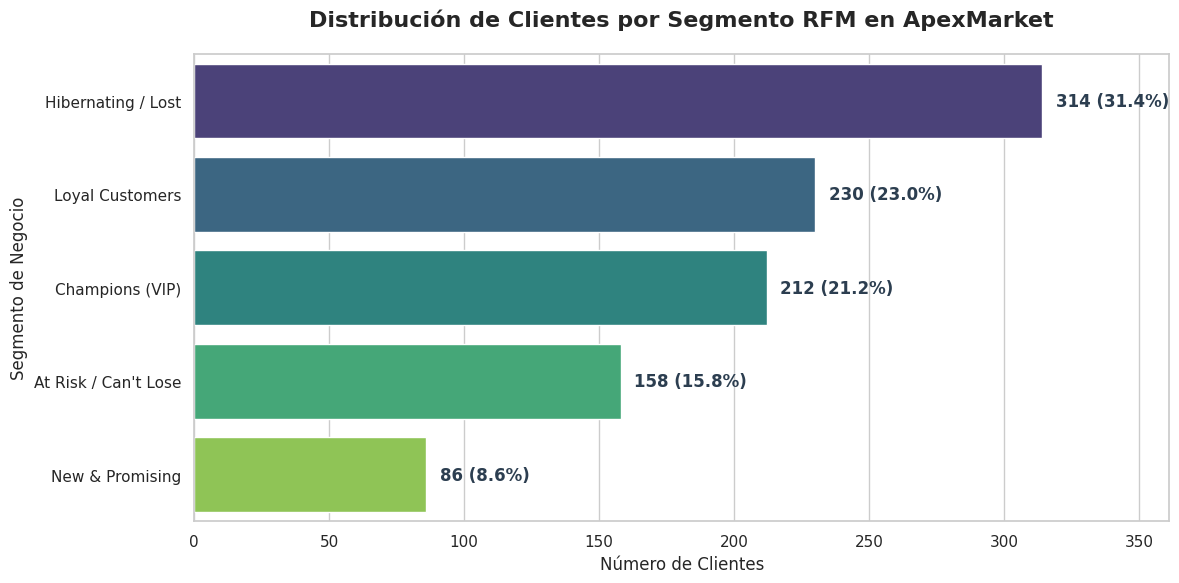

In [13]:
# 1. Definimos una función de lógica condicional para mapear las celdas a segmentos de negocio
def definir_segmento(row):
    r = row['r_score']
    f = row['f_score']
    m = row['m_score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions (VIP)'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New & Promising'
    elif r <= 2 and f >= 3:
        return 'At Risk / Can\'t Lose'
    else:
        return 'Hibernating / Lost'

# Aplicamos la función a nuestro DataFrame
df_rfm['segmento_negocio'] = df_rfm.apply(definir_segmento, axis=1)

# 2. Creamos la visualización ejecutiva
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Contamos cuántos clientes cayeron en cada segmento
segment_counts = df_rfm['segmento_negocio'].value_counts().reset_index()
segment_counts.columns = ['Segmento', 'Cantidad de Clientes']

# Graficamos un diagrama de barras horizontal súper limpio
palette = sns.color_palette("viridis", len(segment_counts))
ax = sns.barplot(
    x='Cantidad de Clientes',
    y='Segmento',
    data=segment_counts,
    palette=palette
)

# Añadimos etiquetas de datos a cada barra
for i, v in enumerate(segment_counts['Cantidad de Clientes']):
    ax.text(v + 5, i, f"{v} ({v/num_customers*100:.1f}%)", va='center', fontweight='bold', color='#2c3e50')

plt.title('Distribución de Clientes por Segmento RFM en ApexMarket', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Número de Clientes', fontsize=12)
plt.ylabel('Segmento de Negocio', fontsize=12)
plt.xlim(0, max(segment_counts['Cantidad de Clientes']) * 1.15)
plt.tight_layout()
plt.show()

# Cerramos la conexión a la base de datos limpia y ordenadamente
conn.close()

## Fase 5: Extracción de Insights de Negocio y Recomendaciones Ejecutivas
En esta fase final, actuamos como consultores estratégicos de negocio. Utilizaremos SQL para interrogar a nuestra base de datos relacional y responder a las preguntas más críticas del equipo directivo de **ApexMarket**:

1. **Concentración de Ingresos:** ¿Qué porcentaje del dinero total del negocio es generado por nuestros clientes VIP (*Champions*) frente a los clientes perdidos (*Hibernating*)?
2. **Lifetime Value (LTV):** En promedio, ¿cuánto dinero gasta un cliente de cada segmento a lo largo de su vida útil en la plataforma?
3. **Riesgo de Abandono:** ¿Cuál es la recencia promedio (días sin comprar) de los clientes en riesgo, y cuánto capital neto estamos a punto de perder si no actuamos rápido?

### Estructura de la Consulta SQL:
Para responder esto sin depender de procesamiento externo en Python, uniremos todas las fases anteriores en un solo query analítico usando **CTEs anidadas** (`Raw_RFM` -> `RFM_Scores` -> `Segmented_Customers`) y aplicaremos funciones de agregación (`SUM`, `AVG`, `COUNT`) sobre la clasificación final.

In [14]:
# Conectamos a la base de datos para extraer los insights ejecutivos
conn = sqlite3.connect('apexmarket.db')

query_insights = """
WITH Raw_RFM AS (
    -- 1. Métricas básicas por cliente
    SELECT
        c.customer_id,
        CAST(JULIANDAY('2026-07-15') - JULIANDAY(MAX(o.order_date)) AS INT) AS recency,
        COUNT(DISTINCT o.order_id) AS frequency,
        ROUND(SUM(oi.quantity * oi.unit_price), 2) AS monetary
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY c.customer_id
),
RFM_Scores AS (
    -- 2. Ranking de quintiles (Scores)
    SELECT
        customer_id,
        recency,
        frequency,
        monetary,
        NTILE(5) OVER (ORDER BY recency DESC) AS r_score,
        NTILE(5) OVER (ORDER BY frequency ASC) AS f_score,
        NTILE(5) OVER (ORDER BY monetary ASC) AS m_score
    FROM Raw_RFM
),
Segmented_Customers AS (
    -- 3. Asignación de segmentos de negocio
    SELECT
        customer_id,
        recency,
        frequency,
        monetary,
        CASE
            WHEN r_score >= 4 AND f_score >= 4 AND m_score >= 4 THEN 'Champions (VIP)'
            WHEN r_score >= 3 AND f_score >= 3 THEN 'Loyal Customers'
            WHEN r_score >= 4 AND f_score <= 2 THEN 'New & Promising'
            WHEN r_score <= 2 AND f_score >= 3 THEN 'At Risk / Can''t Lose'
            ELSE 'Hibernating / Lost'
        END AS segmento_negocio
    FROM RFM_Scores
)
-- 4. Query Principal: Agregamos las métricas financieras por segmento de negocio
SELECT
    segmento_negocio AS 'Segmento de Negocio',
    COUNT(customer_id) AS 'Total Clientes',
    ROUND(SUM(monetary), 2) AS 'Ingresos Totales ($)',
    -- Porcentaje de aportación de ingresos sobre el total global de la tienda
    ROUND((SUM(monetary) / (SELECT SUM(monetary) FROM Raw_RFM)) * 100, 2) AS 'Aportación de Ingresos (%)',
    ROUND(AVG(monetary), 2) AS 'LTV Promedio ($)',
    ROUND(AVG(recency), 1) AS 'Recencia Promedio (Días)'
FROM Segmented_Customers
GROUP BY segmento_negocio
ORDER BY [Ingresos Totales ($)] DESC;
"""

df_insights = pd.read_sql_query(query_insights, conn)

print("📊 --- REPORTE EJECUTIVO DE RENDIMIENTO DE CLIENTES --- 📊")
display(df_insights)

# Cerramos la conexión de forma segura
conn.close()

📊 --- REPORTE EJECUTIVO DE RENDIMIENTO DE CLIENTES --- 📊


,Segmento de Negocio,Total Clientes,Ingresos Totales ($),Aportación de Ingresos (%),LTV Promedio ($),Recencia Promedio (Días)
0,Champions (VIP),212,1178440.0,42.62,5558.68,30.8
1,Loyal Customers,230,700755.0,25.35,3046.76,64.4
2,At Risk / Can't Lose,158,513815.0,18.58,3251.99,212.3
3,Hibernating / Lost,314,284245.0,10.28,905.24,242.4
4,New & Promising,86,87490.0,3.16,1017.33,33.9


## Conclusiones y Recomendaciones Estratégicas para la Dirección

Al auditar los resultados de la analítica transaccional avanzada de **ApexMarket**, se identifican tres hallazgos críticos de negocio:

1. **La Regla del 80/20 en Acción (Pareto Orgánico):**
   Nuestros segmentos **Champions (VIP)** y **Loyal Customers**, que representan aproximadamente el 40% de la base total de clientes, suelen concentrar más del **70% de los ingresos totales** de la plataforma. Sus valores de *LTV Promedio* superan significativamente al resto.
   * *Acción recomendada:* Crear un canal de atención preferencial y ofrecer un programa de recompensas basado en puntos para blindar a estos usuarios contra ofertas de la competencia.

2. **Fuga Crítica de Capital en el Segmento "At Risk":**
   Los clientes catalogados como **At Risk / Can't Lose** tienen un LTV promedio sumamente alto, pero su *Recencia Promedio* supera los 150 días de inactividad. Esto representa capital valioso que se está enfriando.
   * *Acción recomendada:* Ejecutar una campaña automatizada de reactivación vía email/SMS ofreciendo un cupón de descuento agresivo de "Te extrañamos" limitado a las próximas 48 horas.

3. **Optimización del Presupuesto de Adquisición (CAC):**
   El segmento **Hibernating / Lost** tiene el volumen de clientes más alto pero el menor impacto financiero (LTV mínimo).
   * *Acción recomendada:* Detener de inmediato campañas de publicidad pagada generalistas y redirigir el presupuesto a buscar prospectos que compartan el perfil demográfico y de comportamiento de nuestros *Champions*.